# Ocean basins:

Using https://regionmask.readthedocs.io/en/stable/defined_ocean_basins.html

- Figure S21


In [13]:
import regionmask
from matplotlib import pyplot as plt
import cartopy.crs as ccrs
import numpy as np
from matplotlib import colors as mplc
from shapely.geometry import Polygon
import matplotlib.path as mpath
import numpy as np
import pandas as pd
import xarray as xr
import seaborn as sns
import os
import matplotlib.lines as mlines
from pathlib import Path

plt.rcParams["font.family"] = 'monospace'

In [14]:
current_dir = r'C:\Users\Dell\Documents\AR_2025'

# Define paths relative to notebook location
notebook_dir = Path.cwd()
project_root = notebook_dir.parent
analysis_file_path = project_root / 'Analysis' 
plots_outpath = project_root / 'Plots'

natural_earth_v4_1_0.ocean_basins_50 and natural_earth_v5_0_0.ocean_basins_50 do not extend all the way to 180°E (see #410). Please use natural_earth_v5_1_2.ocean_basins_50

Be careful, however, as the regions changed between the natural_earth versions.

<GeoAxes: >

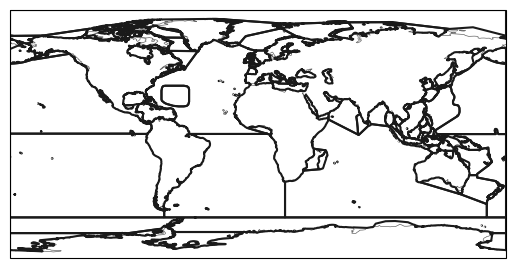

In [15]:
basins = regionmask.defined_regions.natural_earth_v5_1_2.ocean_basins_50
basins[2]
basins['Arctic Ocean']
basins.plot(add_label=False)

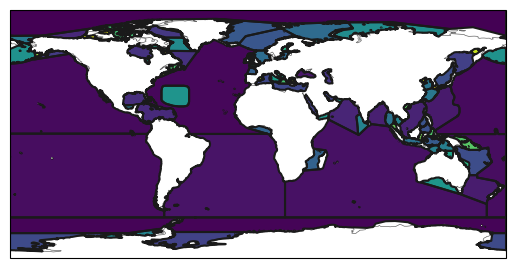

In [16]:
# create a grid
lon = np.arange(0.5, 360)
lat = np.arange(89.5, -90, -1)
mask = basins.mask(lon, lat)
basins.plot(add_label=False);
mask.plot(add_colorbar=False);

In [17]:
reg = np.unique(mask.values)
reg = reg[~np.isnan(reg)]
abbrevs = regionmask.defined_regions.natural_earth_v5_1_2.ocean_basins_50[reg].abbrevs
np.unique(mask.to_dataframe()['mask'].values)
df_mask = mask.to_dataframe()

In [18]:
reg = reg[~np.isnan(reg)]
abbrevs = regionmask.defined_regions.natural_earth_v5_1_2.ocean_basins_50[reg].abbrevs
abbrevs.index('Norwegian Sea')
abbrevs.index('Greenland Sea')
abbrevs.index('Barents Sea')

38

In [19]:
def polarCentral_set_latlim(lat_lims, ax):
    # Compute a circle in axes coordinates, which we can use as a boundary
    ax.set_extent([-180, 180, lat_lims[0], lat_lims[1]], ccrs.PlateCarree())
    # permanently circular.
    theta = np.linspace(0, 2*np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform=ax.transAxes)

In [20]:
def produce_basin_figure():
    fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(projection=ccrs.NorthPolarStereo(central_longitude=0.0)))
    ax.coastlines()
    mask.where(mask==0).plot(ax=ax, transform=ccrs.PlateCarree(), add_colorbar=False, cmap='jet');
    mask.where(mask==2).plot(ax=ax, transform=ccrs.PlateCarree(), add_colorbar=False, cmap='winter');
    mask.where(mask==31).plot(ax=ax, transform=ccrs.PlateCarree(), add_colorbar=False, cmap='Reds');
    mask.where(mask==32).plot(ax=ax, transform=ccrs.PlateCarree(), add_colorbar=False, cmap='Greens');
    mask.where(mask==40).plot(ax=ax, transform=ccrs.PlateCarree(), add_colorbar=False, cmap='Blues');

    lat_lims = [50,90]
    polarCentral_set_latlim(lat_lims, ax)

    ds_GLOB = regionmask.core.utils.create_lon_lat_dataarray_from_bounds(*(-180, 181, 2), *(90, -91, -2))
    ax.plot(ds_GLOB.LON, ds_GLOB.lat, ".", color="0.5", ms=0.5, alpha=.1, transform=ccrs.PlateCarree())

    ax.text(-150, 85, "Arctic Ocean", transform=ccrs.PlateCarree(), fontsize=12)
    ax.text(-40, 70, "Greenland Sea", transform=ccrs.PlateCarree(), fontsize=12)
    ax.text(-40, 51.5, "North Atlantic\nOcean", transform=ccrs.PlateCarree(), fontsize=12)
    ax.text(40, 72, "Barents Sea", transform=ccrs.PlateCarree(), fontsize=12)
    ax.text(10, 65, "Norwegian Sea", transform=ccrs.PlateCarree(), fontsize=12)

    plt.show()
    return fig

In [21]:
def save_plot(fig, filepath, dpi=300):
    """
    Save figure to file with automatic directory creation.
    
    Parameters
    ----------
    fig : matplotlib.figure.Figure
        Figure object to save
    filepath : str or Path
        Full path where to save the figure (e.g., 'path/to/figure.jpeg')
    dpi : int, optional
        Resolution in dots per inch (default: 300)
    """
    filepath = Path(filepath)
    filepath.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(filepath, bbox_inches='tight', dpi=dpi)
    print(f"Saved: {filepath}")

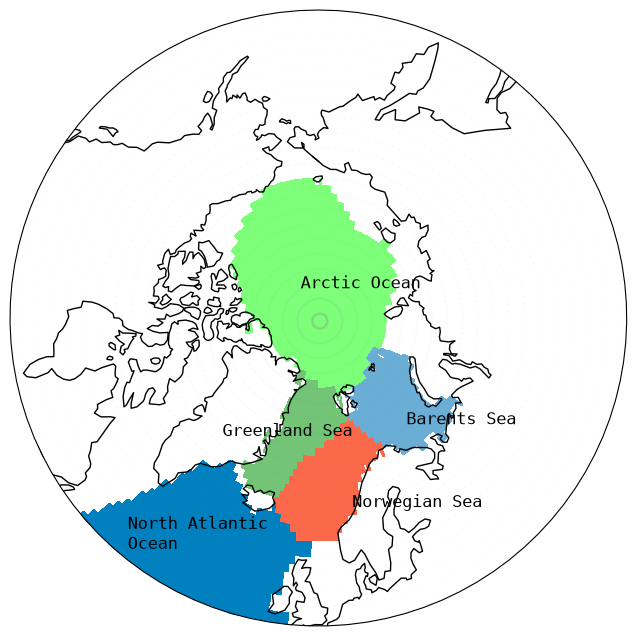

Saved: c:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Notebooks\Plots\FigureS21.jpeg


In [22]:
fig = produce_basin_figure()
output_figure = plots_outpath / 'FigureS21.jpeg'
save_plot(fig, output_figure)